In [1]:
import numpy as np 
import os

import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit,brentq
from scipy.integrate import ode, odeint

import Physical_Const as phys
import WD_HT as WD

#----Constants------

hbar     = phys.hbar
c        = phys.c
G        = phys.G
sigma    = phys.sigmaSB
me_mev   = phys.me
e        = phys.e
e_erg    = phys.e_erg
mevtoerg = phys.mevtoerg
mu       = phys.mu
kappaB   = phys.kappa
Msun     = phys.Msun
Rsun     = phys.Rsun

h        = hbar*(2.0*np.pi)
c2       = c*c
me       = me_mev * mevtoerg / c2


# ---Dimensions---
MA       = 2.0
Cgrav    = G * Msun / c**2
Jdim     = G / c**3

mpl      = np.sqrt(hbar * c / G) # planck mass
Rdim     = np.power( mpl / me , 2.0) * hbar / (mpl * c)
Mdim     = Rdim / Cgrav
Sigma02  = np.power( c / Rdim,2.0) / G

Sigma    = np.power(me,4.0)*np.power(c,3.0)/(8.0*np.power(np.pi,2.0)*np.power(hbar,3.0))
SigmaP   = c2 * Sigma

Bdim     =  np.sqrt(G )  * Rdim / c2  
Jadim    = 1e50
JJdim    = Jadim * Jdim  / Rdim**2

rhobeta  = np.log10(3.9e10)


/home/laura/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# RMFT EOS
rhoEoS, xeEoS, PEoS, PsatEoS, chip_EoS = np.loadtxt("../C12_with_elec_energy.dat",usecols=(0,1,2,3,4),unpack=True)
rhoi  = np.log10( rhoEoS[0] )
rhof  = np.log10( rhoEoS[-1] )
xemin = xeEoS[0]
xemax = xeEoS[-1]
NN    = 100

# --- Degenerate electronic Pressure -----
def Pch_EoS(x):

    x2  = x*x
    
    if x > 2e-3:
        ww  = np.sqrt( 1.0 + x2) + x 
        pWD = x * np.sqrt( 1.0 + x2 ) * ( 2.0 * x2/3.0  - 1.0 ) +  np.log( ww ) 
    else:
        x3 = x2*x
        x5 = x3*x2
        x7 = x5*x2
        x9 = x7*x2
        x11 = x9*x2
        pWD = -2.77556e-17*x3 + 0.533333*x5 - 0.190476*x7 + 0.111111*x9 - 0.0757576*x11
    
    #pWD = SigmaP*(x*np.sqrt(1.0+np.power(x,2.0))*(2.0*np.power(x,2.0)/3.0-1.0)+np.log(np.sqrt(1.0+np.power(x,2.0))+x))
    return SigmaP * pWD

def func(x, b):
    return ( np.power(10.0,rhof) / Sigma02 ) * np.power(x,b)/np.power(xemax,b)

# --- Magnetic field -----
def Magnetic(rho, Bs, B0):
    rho0    = 1e9 /  Sigma02
    x       = rho / rho0
    eta     = 0.8
    gamma   = 0.9
    
    Bfield  = Bs + B0*( 1.0 - np.exp( -eta * x**gamma ) )
    DBfield =  B0 *  np.exp( -eta * x**gamma )  * ( eta * gamma * x**(gamma - 1.0) ) / rho0
    
    return  [ Bfield, DBfield ]
    

#---find best fit-----
popt, pcov = curve_fit(func, xeEoS , rhoEoS / Sigma02)
afit = popt[0]

log_xXe = np.linspace(np.log10(xeEoS[0]*0.05),np.log10(xeEoS[-1]*1.5),NN)
xx_xe   = np.power(10.0,log_xXe)

Bwd     = [ [0,0], [1e9,1e13],[1e7, 1e14],[1e9, 1e14]]
Nb      = len(Bwd)

EOSs    = np.zeros((Nb,2,NN))

#Create grid to fit fuction and calculate denrivatives EoS-------
for j in range(Nb):
    Bs = Bwd[j][0] * Bdim
    B0 = Bwd[j][1] * Bdim
    
    for i in range(NN):
        xi = xx_xe[i]
        PP = Pch_EoS(xi)
        rw = func(xi,afit)
        BB = Magnetic(rw, Bs, B0 )
        B2 = BB[0]**2.0
        EOSs[j, 0, i] = rw + B2 / ( 8.0 * np.pi )
        EOSs[j, 1, i] = PP / ( c**2*Sigma02 ) + B2 / ( 8.0 * np.pi )

DeDp_2 = np.zeros((Nb,NN))
DxeF   = 0.01
for j in range(Nb):
    Bs = Bwd[j][0] * Bdim
    B0 = Bwd[j][1] * Bdim
    
    for i in range(NN):
        dx = xx_xe[i]*DxeF
        xi = xx_xe[i] + dx
        PP = Pch_EoS(xi)
        rw = func(xi, afit)
        BB = Magnetic(rw, Bs, B0 )
        B2 = BB[0]**2.0

        rhor = rw + B2 / ( 8.0 * np.pi )
        Pr   = PP / ( c**2*Sigma02 ) + B2 / ( 8.0 * np.pi )
        
        if i==0:
            Der = (rhor - EOSs[j,0][i]) / ( Pr - EOSs[j,1][i])
        
        else:

            xi = xx_xe[i] - dx
            PP = Pch_EoS(xi)
            rw = func(xi, afit)
            BB = Magnetic(rw, Bs, B0 )
            B2 = BB[0]**2.0

            rhol = rw + B2 / ( 8.0 * np.pi )
            Pl   = PP / ( c**2*Sigma02 ) + B2 / ( 8.0 * np.pi )
            Der = (rhor-rhol) / ( Pr - Pl )
        DeDp_2[j,i] = Der



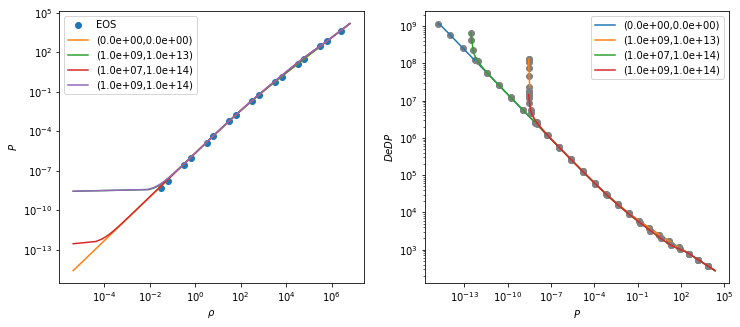

In [3]:
fig = plt.figure(figsize=(12,5))
frm_ls = [f"({val[0]:.1e},{val[1]:.1e})" for val in Bwd]

plt.subplot(121)
x    = np.linspace(rhoi,rhof,100)
plt.loglog( rhoEoS/Sigma02, [ Pch_EoS(xeEoS[i])/ ( c**2*Sigma02 ) for i in range(len(xeEoS))] ,'o', label="EOS")

for j in range(Nb):

    EoS_RFMT    = interp1d( EOSs[j,0], EOSs[j,1], kind='cubic' )
    EoS_RFMT_02 = interp1d( EOSs[j,1], EOSs[j,0], kind = 'cubic')
    
    Pmin = np.log10(EOSs[j,1][1])
    Pmax = np.log10(EOSs[j,1][-2])
    xp   = np.linspace(Pmin,Pmax,100)

    #plt.loglog( np.power(10,x)/Sigma02, EoS_RFMT(np.power(10,x)/Sigma02), 'b-', label="interp")
    plt.loglog( EoS_RFMT_02(np.power(10,xp)), np.power(10,xp), label = frm_ls[j]   )
    #plt.loglog( EOS1[0], EOS1[1],'k:')

plt.legend()

plt.xlabel("$\\rho$")
plt.ylabel("$P$")

plt.subplot(122)
#---Plot derivative EoS-----
for j in range(Nb):
    DeDpF   = interp1d(np.log10(EOSs[j][1]),  np.log10(DeDp_2[j]),kind='cubic')
    Pmin = np.log10(EOSs[j,1][0]) 
    Pmax = np.log10(EOSs[j,1][-1])
    
    x    = np.linspace(Pmin,Pmax,100)
    
    plt.loglog(EOSs[j,1][::4],DeDp_2[j][::4],'o', color="gray")
    plt.loglog(np.power(10,x),np.power(10,DeDpF(x)),'-',  label = frm_ls [j])

plt.xlabel("$P$")
plt.ylabel("$DeDP$")
plt.legend()

plt.show()


## TOV Equations: Non-Rotating case

$$ \frac{dm}{dr}=4\pi r^2 \rho $$
$$ \frac{d\nu}{dr}=\frac{2(4\pi r^3 p +m)}{r(r-2m)} $$
$$ \frac{dp}{dr}=-\frac{1}{2}(p+\rho)\frac{d\nu}{dr}$$

### TOV: HT Rotating Case (up to first order in $\Omega$)
$$ \frac{d\omega}{dr}=f$$
$$ \frac{df}{dr} = \frac{4\pi r^2 (p+\rho) }{r-2m}\left(\frac{4\omega}{r}+f\right) -4\frac{f}{r}$$

### TOV: HT Rotating Case (up to second order in $\Omega$)
$$\frac{dm_0}{dr}= 4\pi r^2 \rho_{l=0} + \frac{8}{3}e^{-\nu}\pi r^4 (p+\rho)\omega^2 + \frac{1}{12}e^{-\nu}r^3(r-2m)\left(\frac{d\omega}{dr}\right)^2$$

$$ \frac{dp^{*}_0}{dr}=-\frac{m_0(1+8\pi r^2 p)}{(r-2m)^2 }-\frac{4\pi r^2 P_{l=0}}{r-2m} +\frac{1}{3}e^{-\nu}\left(\omega^2 (2r-r^2\frac{d\nu}{dr}) +2r^2\omega\frac{d\omega}{dr} +\frac{r^3}{4}\left(\frac{d\omega}{dr}\right)^2\right)$$

$$ \rho_{l=0} = p^{*}_{l=0}(p+\rho)\frac{dE}{dP} $$
$$ P_{l=0} = p^{*}_{l=0}(p+\rho) $$

$$ \frac{dv}{dr}=-h_2\frac{d\nu}{dr} + \frac{1}{2}e^{-\nu}\left(2+r\frac{d\nu}{dr}\right) \left[\frac{8}{3} \pi \omega^2 r^3(p+\rho) + \frac{1}{6}r^2(r-2m)\left(\frac{d\omega}{dr}\right)^2\right]$$

$$ \frac{dh_2}{dr}= -h_2\frac{d\nu}{dr} - \frac{4h_2(m -2\pi r^3 (p+\rho))}{r^2(r-2m) \nu'}-\frac{2v}{m+4\pi r^3p}+ \frac{e^{-\nu}}{6}\left[\frac{-r^2}{ \nu'} + \frac{r^3(r-2m)\nu'}{2 }\right]\left(\frac{d\omega}{dr}\right)^2 +\frac{4\pi r^3 (p+\rho)\omega^2 e^{-\nu}}{3}\left(r\nu' +\frac{2}{(r-2m)\nu'}\right)$$

In [4]:
dr = 5e-7
rf = 1.0

#----Calculating maximun mass of Static sequence
Mmax_wd = np.zeros((Nb,2))

for j in range(Nb):
    
    Mmax = WD.EoS_Mmax( np.power(10.0,rhoi*2)/Sigma02, np.power(10.0,rhof)/Sigma02, dr, rf, EOSs[j])
    print(j, frm_ls[j], Mmax[1]*Mdim)
    Mmax_wd[j] = Mmax

0 (0.0e+00,0.0e+00) 1.3796519682639925
1 (1.0e+09,1.0e+13) 1.3816618363988846
2 (1.0e+07,1.0e+14) 1.8499461475454912
3 (1.0e+09,1.0e+14) 1.8499796714042245


In [5]:
# Keplrian Sequence

#file_name = "./KepSeqWDBfield_RMTF.dat"
file_name0 = "./KepSeqWD_Bf"
frm = [f"{val[0]:.0E}_{val[1]:.0E}" for val in Bwd]
writeKep = True

Nm      = 20
MR_kep  = np.zeros((Nb,Nm, 8))
rho_kep = np.zeros( ( Nb,Nm ) )

for j in range(Nb):
    print("#######", j, frm_ls[j])
    file_name = "".join([file_name0, frm[j]])
    file_name = "".join([file_name,".dat"])

    print( file_name )

    EoS_RFMT    = interp1d( EOSs[j,0], EOSs[j,1], kind='cubic' )
    DeDpF   = interp1d(np.log10(EOSs[j][1]),  np.log10(DeDp_2[j]),kind='cubic')
    
    rhomaxS = np.log10(Mmax_wd[j][0]*Sigma02)
    rhocc   = np.linspace(rhoi*2.5, rhobeta,Nm)
    rhons   = np.power(10.0,rhocc)/Sigma02
    pc      = EoS_RFMT( rhons )

    rho_kep[j] = rhocc 
    
    if not writeKep:
        if os.path.isfile(file_name):
            print("The keplerian Sequence has been already done......")
            rhowd_kep, pwd_kep, Mstawd_kep, Rstawd_kep, Mrotwd_kep, Rrotwd_kep, Jwd_kep, Omegawd_kep =np.loadtxt(file_name,usecols=(0,1,2,3,4,5,6,7),unpack=True)

    else:
        for i in range(Nm):
            
            dedp0 = np.power(10, DeDpF( np.log10( pc[i] ) ))
            y0i   = WD.IntCond_Static( rhons[i], pc[i], dr )
            MS    = WD.StaticSeq( y0i , dr, rf, EOSs[j] )
        
            OK    = WD.OmegaK( MS[0], MS[1], 0, 0 , 0 )
    
            y0i   = WD.IntCond_Rotating( OK, MS[4], rhons[i], pc[i], MS[2], dr , rf , EOSs[j], dedp0 )   
            MR    = WD.MassRadius(y0i, dr, rf,  EOSs[j], DeDp_2[j] )

            OK    = WD.OmegaK( MR[0] , MR[1] , 0.0,  MR[3] / MR[0]**2.0, 0.0*MR[5] / MR[0]**3.0 )
            cut = 0
            while np.abs(MR[4]-OK)>1e-4 and cut<80:
                y0i = WD.IntCond_Rotating( OK, MS[4], rhons[i], pc[i], MS[2], dr , rf , EOSs[j], dedp0 )   
                MR  = WD.MassRadius(y0i, dr, rf,   EOSs[j], DeDp_2[j] )
                OK  = WD.OmegaK( MR[0] , MR[1] , 0.0,  MR[3] / MR[0]**2.0, 0.0*MR[5] / MR[0]**3.0 )
                cut += 1
            
            MR_kep[j][i] = MR
            print( i, MR[4], OK)
            
        with open(file_name, "w") as file:
            for i in range(Nm):
                line1 = [ rhocc[i], pc[i], MR_kep[j,i][0], MR_kep[j,i][1], MR_kep[j,i][6], MR_kep[j,i][7], MR_kep[j,i][3], MR_kep[j,i][4] ]
                np.savetxt(file,[line1], fmt='%.8e')
                file.flush()

    

####### 0 (0.0e+00,0.0e+00)
./KepSeqWD_Bf0E+00_0E+00.dat
0 13.399931955459637 13.39994500839168
1 16.198438162143475 16.198382940117593
2 19.649630716261356 19.64967320532953
3 23.708094172721005 23.708117482997544
4 28.551384021920605 28.55137505529983
5 34.322351581386904 34.322349184540876
6 41.22347426577945 41.22346813746532
7 49.493401080524364 49.49339582413296
8 59.399000476775676 59.3989975070656
9 71.39202182237354 71.39200146630694
10 85.93028900550866 85.9302716404759
11 103.52491457161378 103.52488341145056
12 125.08748445554677 125.08744078301264
13 151.47796209521988 151.47790563905656
14 184.3260256303373 184.32593496594203
15 224.19621541111223 224.1962160823694
16 273.06988134382425 273.06988732795634
17 336.12553987186016 336.1255399620447
18 412.8254714126558 412.8254715515179
19 507.1388563761458 507.1388796099428
####### 1 (1.0e+09,1.0e+13)
./KepSeqWD_Bf1E+09_1E+13.dat
0 13.238015697570162 13.238007767566415
1 16.16292976138547 16.162960797583153
2 19.630949492845

In [12]:
# Secular Instability Sequence
file_name0 = "./SecInsBfield_"
writeSec = True

dr = 5e-7
rf = 1.0

Nm       = 50
MR_wdmax = np.zeros((Nb, Nm, 8))
rhomax   = np.zeros((Nb, Nm))

for j in range(Nb):
    print("#######", j, frm_ls[j])

    file_name = "".join([file_name0, frm[j]])
    file_name = "".join([file_name,".dat"])

    print( file_name )

    EoS_RFMT    = interp1d( EOSs[j,0], EOSs[j,1], kind='cubic' )
    DeDpF   = interp1d(np.log10(EOSs[j][1]),  np.log10(DeDp_2[j]),kind='cubic')
    
    minj = 1e-3*(MR_kep[j,:][3]*1e13).min()
    maxj = 8e-1# (Jwd_kep*1e13)[-1]
    
    j_grid = np.linspace( minj, maxj, num=Nm)
    
    if not writeSec:
        if os.path.isfile(file_name):
            print("The Secular Instability Sequence has been already done......")
            rhowd_seq,pwd_seq,Mstawd_seq,Rstawd_seq,Mrotwd_seq,Rrotwd_seq,Jwd_seq,Omegawd_seq,Qwd_seq,Omegakwd_seq=np.loadtxt(file_name,usecols=(0,1,2,3,4,5,6,7,8,9),unpack=True)
    else:
        for i in range(Nm):
            
            WDmax = WD.EoS_RoTMmax( np.power(10.0,rhoi*3)/Sigma02, np.power(10.0,rhof)/Sigma02, 1e-13*j_grid[i], dr, rf, EOSs[j], DeDp_2[j] )
            #print(WDmax[1]*Mdim)

            rhomax[j,i] = WDmax[0]
            pc        = EoS_RFMT(WDmax[0])
            dedpc     = np.power(10,DeDpF( np.log10(pc)) )

            y0i = WD.IntCond_Static( WDmax[0], pc , dr )
            MS  = WD.StaticSeq( y0i , dr, rf, EOSs[j] )
    
            y0i   = WD.IntCond_Rotating( 1e-13*j_grid[i] , MS[3], WDmax[0], pc, MS[2], dr , rf , EOSs[j], dedpc )
            OOp   = WD.MassRadius(y0i, dr, rf,  EOSs[j], DeDp_2[j] )
            MR_wdmax[j,i] = OOp
            
            if np.log10(WDmax[0]*Sigma02)>rhobeta:
                print( i, np.log10( WDmax[0]*Sigma02 ), rhobeta )
                Nm2 = i
                break
                
        with open(file_name, "w") as file:
            for i in range(Nm2):
                pc = EoS_RFMT( rhomax[j,i] )
                OK  = WD.OmegaK(  MR_wdmax[j,i][0] ,  MR_wdmax[j,i][1] ,  0.0,   MR_wdmax[j,i][3] /  MR_wdmax[j,i][0]**2.0,  MR_wdmax[j,i][5] /  MR_wdmax[j,i][0]**3.0 )
                line1 = [ np.log10(rhomax[i]*Sigma02), pc, MR_wdmax[j,i][0], MR_wdmax[j,i][1], MR_wdmax[j,i][6], MR_wdmax[j,i][7], MR_wdmax[i][3], MR_wdmax[j,i][4], MR_wdmax[j,i][4], OK]
                np.savetxt(file,[line1], fmt='%.8e')
                file.flush()


#    rhowd_seq,pwd_seq,Mstawd_seq,Rstawd_seq,Mrotwd_seq,Rrotwd_seq,Jwd_seq,Omegawd_seq,Qwd_seq,Omegakwd_seq=np.loadtxt(file_name,usecols=(0,1,2,3,4,5,6,7,8,9),unpack=True)



####### 0 (0.0e+00,0.0e+00)
./SecInsBfield_0E+00_0E+00.dat
0 10.598882378734446 10.5910646070265
####### 1 (1.0e+09,1.0e+13)
./SecInsBfield_1E+09_1E+13.dat
0 10.598882378745735 10.5910646070265
####### 2 (1.0e+07,1.0e+14)
./SecInsBfield_1E+07_1E+14.dat
0 10.598717093136337 10.5910646070265
####### 3 (1.0e+09,1.0e+14)
./SecInsBfield_1E+09_1E+14.dat
0 10.598882379862546 10.5910646070265


(0.0005, 0.015)

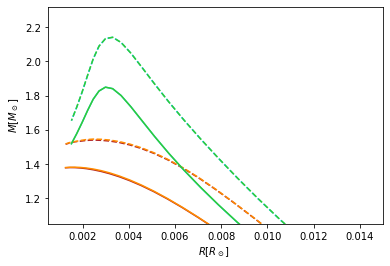

In [13]:
colors= ["Firebrick", "DarkOrange", "DeepSkyBlue", "LimeGreen"]

for j in range(Nb):
    plt.plot(  MR_kep[j,:,1]*Rdim/Rsun,   MR_kep[j,:,0]*Mdim , color=colors[j], label= frm_ls[j])
    plt.plot(  MR_kep[j,:,7]*Rdim/Rsun,   MR_kep[j,:,6]*Mdim , color=colors[j], ls="--")

    plt.plot(  MR_wdmax[j,:,7]*Rdim/Rsun,   MR_wdmax[j,:,6]*Mdim , color=colors[j], ls=":")
    #plt.plot( rhowd_kep,   Mrotwd_kep*Mdim , "k-")

plt.xlabel( "$R [R_\\odot]$  ")
plt.ylabel( "$M [M_\\odot]$")

plt.ylim(1.05,2.32)
plt.xlim(0.0005,0.015)

In [14]:
dr = 1e-6
rf = 1.0

Nm  = 15
MWD = 1.39
#MrotCons = np.zeros((Nb, Nm))
MR_c     = np.zeros((Nb,Nm, 8))
rho_cons = np.zeros((Nb, Nm))
p_cons   = np.zeros((Nb, Nm))

for j in range(Nb):
    print("#######", j, frm_ls[j])

    EoS_RFMT    = interp1d( EOSs[j,0], EOSs[j,1], kind='cubic' )
    DeDpF   = interp1d(np.log10(EOSs[j][1]),  np.log10(DeDp_2[j]),kind='cubic')
    
    Mmax_sta = MR_kep[j,:,0].max()
    Mmax_rot = MR_kep[j,:,6].max() 
    
    print("#############################################################")
    print("Maximun static mass: ", Mmax_sta*Mdim )
    print("Maximun rotating mass: ", Mmax_rot*Mdim )
    print("#############################################################")
    
    imax = MR_kep[j,:,6].argmax()
    Kep_rho = interp1d( MR_kep[j,:imax,6]*Mdim, rho_kep[j,:imax], kind='cubic' )
    imax = MR_kep[j,:,0].argmax()
    Sta_rho = interp1d( MR_kep[j,:imax,0]*Mdim, rho_kep[j,:imax], kind='cubic' )
    
    # define range in the density
    XKep = Kep_rho(MWD)
    
    if MWD<( Mmax_sta*Mdim) :
        Xsta = Sta_rho(MWD)
    else:
        Xsta = rhobeta
        
    rho_grid  = np.linspace( XKep, Xsta-0.01, num=Nm)
    rhoc_grid = np.power(10.0, rho_grid) / Sigma02

    pc_grid   = EoS_RFMT(rhoc_grid)
    dedp_grid = DeDpF( np.log10( pc_grid ) )
    dedp_grid = np.power(10, dedp_grid)

    rho_cons[j] = rho_grid
    p_cons[j]   = pc_grid
    
    for i in range(Nm):
        #print( i, rhoc_grid[i], pc_grid[i])

        y0i = WD.IntCond_Static( rho_grid[i], pc_grid[i], dr )
        MS  = WD.StaticSeq( y0i , dr, rf, EOSs[j] )
        
        Ji = 0.0
        Jl = 10*1e50*G/(Rdim**2*np.power(c,3))
        
        y0i   = WD.IntCond_Rotating( 0.5*(Ji+Jl), MS[3], rho_grid[i], pc_grid[i], MS[2], dr , rf , EOSs[j], dedp_grid[i] )
        OOp   = WD.MassRadius(y0i, dr, rf,  EOSs[j], DeDp_2[j] )
        cut   = 0
        
        while np.abs( OOp[6]*Mdim - MWD ) > 1e-3 and cut<50:
            if OOp[6]*Mdim-MWD > 0.0:
                Jl = (Ji+Jl)/2.0
            else:
                Ji = (Ji+Jl)/2.
                
            y0i   = WD.IntCond_Rotating( 0.5*(Ji+Jl), MS[3], rho_grid[i], pc_grid[i], MS[2], dr , rf ,  EOSs[j], dedp_grid[i] )
            OOp   = WD.MassRadius(y0i, dr, rf,  EOSs[j], DeDp_2[j] )
            cut=cut+1
    
        MR_c[j,i] = OOp
    


####### 0 (0.0e+00,0.0e+00)
#############################################################
Maximun static mass:  1.3795777033120593
Maximun rotating mass:  1.5402520589407347
#############################################################
####### 1 (1.0e+09,1.0e+13)
#############################################################
Maximun static mass:  1.381596802037153
Maximun rotating mass:  1.5458811777167105
#############################################################
####### 2 (1.0e+07,1.0e+14)
#############################################################
Maximun static mass:  1.849095884229536
Maximun rotating mass:  2.1404351171734497
#############################################################
####### 3 (1.0e+09,1.0e+14)
#############################################################
Maximun static mass:  1.8491278841404757
Maximun rotating mass:  2.1404862261273445
#############################################################


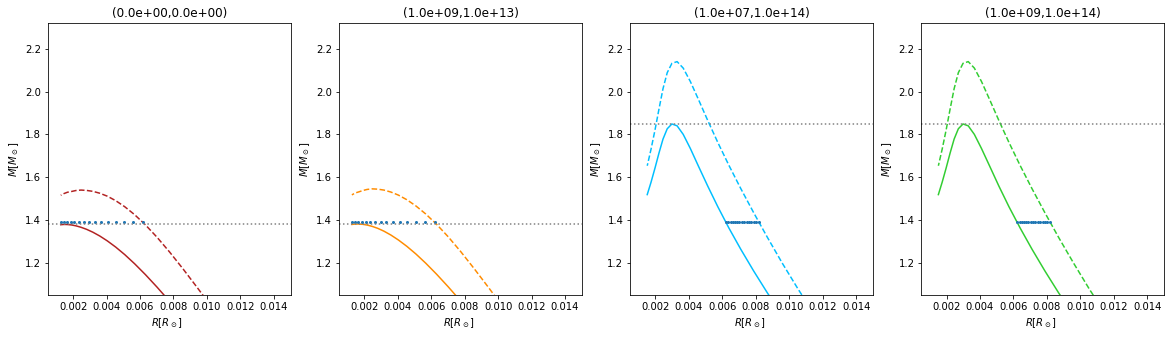

In [15]:
import matplotlib.gridspec as gridspec

# Initialize figure and a 3x3 background grid
fig = plt.figure(figsize=(20, 5))
gs = gridspec.GridSpec(nrows=1, ncols=Nb, figure=fig)

# Top row spans all columns
for j in range(Nb):
    ax1 = fig.add_subplot(gs[0, j])

    ax1.plot(  MR_kep[j,:,1]*Rdim/Rsun,   MR_kep[j,:,0]*Mdim , color=colors[j])
    ax1.plot(  MR_kep[j,:,7]*Rdim/Rsun,   MR_kep[j,:,6]*Mdim , color=colors[j], ls="--")

    ax1.plot(  MR_c[j,:,7]*Rdim/Rsun,   MR_c[j,:,6]*Mdim , marker="o", markersize=2, ls="")

    plt.axhline( y = Mmax_wd[j,1]*Mdim, color = 'gray', ls=':')

    ax1.set_xlabel( "$R [R_\\odot]$  ")
    ax1.set_ylabel( "$M [M_\\odot]$")

    ax1.set_title(frm_ls[j])

    ax1.set_ylim(1.05,2.32)
    ax1.set_xlim(0.0005,0.015)

    #ax1.plot(  MR_wdmax[j,:,7]*Rdim/Rsun,   MR_wdmax[j,:,6]*Mdim , color=colors[j], ls=":")

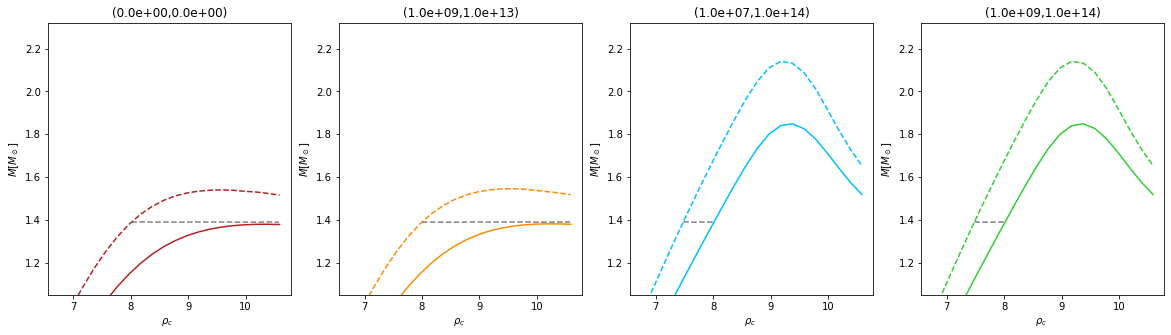

In [16]:
import matplotlib.gridspec as gridspec

# Initialize figure and a 3x3 background grid
fig = plt.figure(figsize=(20, 5))
gs = gridspec.GridSpec(nrows=1, ncols=Nb, figure=fig)

# Top row spans all columns
for j in range(Nb):
    ax1 = fig.add_subplot(gs[0, j])

    ax1.plot(  rho_kep[j,:],   MR_kep[j,:,0]*Mdim , color=colors[j])
    ax1.plot(  rho_kep[j,:],   MR_kep[j,:,6]*Mdim , color=colors[j], ls="--")

    ax1.plot(  rho_cons[j,:],   MR_c[j,:,6]*Mdim , color="gray", ls="--")

    ax1.set_xlabel( "$\\rho_c $  ")
    ax1.set_ylabel( "$M [M_\\odot]$")

    ax1.set_title(frm_ls[j])

    ax1.set_ylim(1.05,2.32)
    #ax1.set_xlim(0.0005,0.015)


    #ax1.plot(  MR_wdmax[j,:,7]*Rdim/Rsun,   MR_wdmax[j,:,6]*Mdim , color=colors[j], ls=":")

In [17]:

file_name0 = "./ConstMassBfield"

for j in range(Nb):
    file_name = "".join([file_name0, frm[j]])
    file_name = "_".join([file_name,str(MWD*100)[0:3]])
    file_name = "".join([file_name,".dat"])

    print(file_name)
    with open(file_name, "w") as file:
        for i in range(Nm):
            OK  = WD.OmegaK(  MR_c[j,i][0] ,  MR_c[j,i][1] ,  0.0,   MR_c[j,i][3] /  MR_c[j,i][0]**2.0,  MR_c[j,i][5] /  MR_c[j,i][0]**3.0 )
            
            line1 = [ rho_cons[j][i], rho_cons[j][i], MR_c[j,i][0], MR_c[j,i][1], MR_c[j,i][6], MR_c[j,i][7],MR_c[j,i][7], MR_c[j,i][3], MR_c[j,i][4], MR_c[j,i][5], OK ]
            np.savetxt(file,[line1], fmt='%.8e')
            file.flush()

./ConstMassBfield0E+00_0E+00_139.dat
./ConstMassBfield1E+09_1E+13_139.dat
./ConstMassBfield1E+07_1E+14_139.dat
./ConstMassBfield1E+09_1E+14_139.dat
